## **Modelagem: XGBoost**

Neste notebook vamos construir e testar um modelo de classificação XGBoost para prever os funcionários que pedirão demissão voluntária.

O XGBoost será nosso terceiro modelo e vamos compará-lo com a regressão logística e o Random Forest.

O processo de modelagem seguirá as seguintes etapas:

- **Pipeline de transformações**: vamos definir um pipeline de transformadores para preparar nossos dados.

- **Tuning do modelo**: vamos usar 10 dobras de validação cruzada para treinar e validar 150 modelos de regressão diferentes, com hiperparâmetros aleatóriamente escolhido no espaço de parâmetros possíveis. Vamos optar pelo modelo que melhor equilibra `recall` e `roc_auc`. 

- **Treinamento do melhor modelo**: vamos selecionar os hiperparâmetros do melhor modelo e treiná-lo no conjunto completo de treinamento

- **Métricas de avaliação no treinamento**: vamos avaliar a acurácia, curva ROC, precisão, recall e f1-score no conjunto de treinamento.

---

Obs: A análise da interpretabiliade será feita com o modelo final escolhido, bem como o teste no conjunto de testes. 

## Importação de Bibliotecas

Nesta etapa são importadas todas as bibliotecas necessárias para **pré-processamento, modelagem e busca de hiperparâmetros**:

1. **Bibliotecas gerais**
   - `numpy` e `pandas`: manipulação de arrays e DataFrames.  
   - `matplotlib.pyplot`: geração de gráficos.  
   - `joblib`: salvar e carregar objetos treinados (como modelos e pipelines).

2. **Transformadores (scikit-learn)**
   - `ColumnTransformer`: aplica diferentes transformações a grupos de colunas.  
   - `OneHotEncoder`, `OrdinalEncoder`, `StandardScaler`, `TargetEncoder`: transformações para variáveis categóricas, ordinais e numéricas.  
   - `PolynomialFeatures`: cria novas features polinomiais a partir das originais.  
   - `KNNImputer`: imputação de valores ausentes com base nos vizinhos mais próximos.  
   - `Pipeline`: encadeia as etapas de pré-processamento e modelagem.

3. **Modelos**
   - `LogisticRegression`: modelo estatístico base usado para classificação.

4. **Busca de hiperparâmetros**
   - `loguniform`, `uniform`: distribuições de probabilidade usadas para amostragem de hiperparâmetros.  
   - `RandomizedSearchCV`: busca aleatória sobre o espaço de hiperparâmetros, combinando treino e validação cruzada.

---

👉 Essas importações organizam as ferramentas que serão usadas para **construir, ajustar e otimizar** o pipeline de machine learning.


In [17]:
### Libs padrão ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

### Modelos ###
from xgboost import XGBClassifier
from category_encoders.target_encoder import TargetEncoder


### Pré-processamento ###
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,TargetEncoder
from sklearn.pipeline import Pipeline

### Validação e busca ###
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint, loguniform


## Carregamento dos Dados de Treino

Neste passo, os arquivos de treino previamente salvos em **CSV** são carregados para o ambiente:

1. **`X_train.csv`**  
   - Contém as variáveis preditoras (features) já separadas para treino.  
   - É lido em um DataFrame `X_train`.

2. **`y_train.csv`**  
   - Contém apenas a variável alvo (target), indicando o desfecho que se deseja prever.  
   - É lido em um DataFrame `y_train`.

---

👉 Esses arquivos foram gerados anteriormente no processo de preparação dos dados (divisão treino/teste) e agora serão usados como entrada para o pipeline de modelagem.


In [18]:
### dados ###
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()  # Converte para array 1D

## Definição dos Grupos de Variáveis

Neste trecho, organizamos todas as colunas do dataset em **grupos de variáveis** de acordo com sua natureza.  
Essa separação facilita o pré-processamento, pois cada tipo de variável exige um tratamento diferente no pipeline.

### Grupos criados:

- **Binárias (`binarias`)**  
  Variáveis com apenas duas categorias possíveis (ex.: *sim/não*, *masculino/feminino*).  
  Exemplos: `catl_sexo`, `catl_doenca_cronica`, `catl_cigarro`.

- **Numéricas (`numericas`)**  
  Variáveis quantitativas contínuas ou discretas que já estão em formato numérico.  
  Exemplos: `num_idade`, `num_idade_diagnostico`, `num_consultas`.

- **Ordinais (`ordinais`)**  
  Variáveis categóricas que possuem **ordem natural** entre as categorias (ex.: níveis de saúde ou de cobertura).  
  Exemplos: `ord_saude`, `ord_limita_asma`, `ord_nivel_plano`.

- **Categóricas (`categoricas`)**  
  Variáveis qualitativas **sem ordem definida** entre as categorias.  
  Exemplos: `catl_cor_raca`, `catl_tipo_de_area`, `cath_material_parede`.

---

👉 Essa estrutura (`tipos_variaveis1`) será usada no **ColumnTransformer** do pipeline para aplicar transformações específicas em cada grupo de variáveis.


In [19]:
# 1) Grupos de variáveis
tipos_variaveis1 = {
    "binarias": [
        "catl_sexo","catl_doenca_cronica","catl_animais","catl_homeopatia",
        "catl_internacao","catl_quimicos","catl_ruidos","catl_sol",
        "catl_material_biologico","catl_plano_saude","catl_medicamentos",
        "catl_plantas_medicinais","catl_deixar_atividades","catl_servico_saude",
        "catl_recebeu_atendimento","catl_lixo","catl_poeira_mineral",
        "catl_plano_consultas","catl_plano_exames","catl_plano_internacoes",
        "catl_cigarro","catl_pagou_remedio","catl_domicilio_cadastrado"
    ],

    "numericas": [
        "num_idade","catl_cachoros","catl_gatos","num_consultas"
    ],

    "ordinais": [
        "ord_saude","ord_agente_saude",
        "ord_nivel_plano","ord_remedio_semana","ord_remedio_sus",
        "ord_farmacia_popular"
    ],

    "categoricas": [
        "catl_cor_raca","catl_tipo_de_area","catl_tipo_de_domicilio",
        "cath_material_parede","cath_fonte_de_agua",
        "catl_destino_do_lixo","catl_atividade","cath_estado_agua",
        "cath_local_atendimento"
    ],

    "alta_cardinalidade": [
        "cath_destino_do_esgoto","cath_trabalho"
    ]
}


### 🗂️ Definição dos grupos de variáveis

Antes de aplicar o pré-processamento, organizamos as variáveis do dataset em grupos, de acordo com sua natureza.  
Essa separação é importante porque cada tipo de variável requer um tratamento específico (imputação, codificação, escalonamento etc.).

- **Binárias (`binarias`)**: variáveis categóricas com apenas duas categorias possíveis (ex.: `catl_sexo`, `catl_doenca_cronica`).
- **Numéricas (`numericas`)**: variáveis quantitativas contínuas ou discretas (ex.: `num_idade`, `num_consultas`).
- **Ordinais (`ordinais`)**: variáveis categóricas que possuem uma ordem natural entre os valores (ex.: `ord_saude`, `ord_remedio_semana`).
- **Categóricas (`categoricas`)**: variáveis qualitativas sem ordem definida (ex.: `catl_cor_raca`, `cath_fonte_de_agua`).
- **Alta cardinalidade (`alta_cardinalidade`)**: variáveis categóricas com grande número de categorias distintas, que serão tratadas com `TargetEncoder` (ex.: `cath_trabalho`, `cath_destino_do_esgoto`).

Esses grupos são usados no `ColumnTransformer` para garantir que cada tipo de dado receba o pré-processamento adequado.


In [20]:
# OneHot compatível (usa esparso quando fizer sentido)
ohe_kwargs = dict(handle_unknown="ignore", dtype=np.float32)
try:
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse_output=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse_output=True, **ohe_kwargs)
except TypeError:  # sklearn<1.2
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse=True, **ohe_kwargs)

# ---- Pipelines ----
num_pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=10)),
    ("scaler", StandardScaler())
])

ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_BIN)
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_CAT)
])

high_card_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target", TargetEncoder())
])



pre = ColumnTransformer(
    transformers=[
        ("numeric",     num_pipe, tipos_variaveis1["numericas"]),
        ("ordinal",     ord_pipe, tipos_variaveis1["ordinais"]),
        ("binary",      bin_pipe, tipos_variaveis1["binarias"]),
        ("categorical", cat_pipe, tipos_variaveis1["categoricas"]),
        ("high_card",   high_card_pipe, tipos_variaveis1["alta_cardinalidade"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
    # IMPORTANTE: não force esparso aqui; deixe o CT decidir
    # sparse_threshold=0.3  # (padrão). Pode omitir.
)

## **Modelo**

## Configuração do Pipeline e Treinamento

A etapa 22 define o `Pipeline` para o modelo de _machine learning_.

**Pré-processamento:** O objeto `pre` (supostamente definido em células anteriores) é aplicado aos dados.
**Classificador:** É utilizado um `XGBClassifier` com 1000 estimadores.
**Balanceamento de Classes:** O parâmetro `scale_pos_weight` é calculado pela razão $N_{negativos} / N_{positivos}$ para compensar o desequilíbrio do _dataset_.

In [21]:
model = XGBClassifier(n_estimators=1000)

In [22]:
# 1) Pipeline: pré-processamento + XGB
from collections import Counter
cnt = Counter(y_train)
scale_pos_weight = cnt[0] / cnt[1]   # ~ 95/5 ≈ 19
print(f"Proporção de classes: {cnt[0]} negativos / {cnt[1]} positivos → scale_pos_weight ≈ {scale_pos_weight:.2f}")
pipeline = Pipeline([
    ("pre", pre),
    ("clf", XGBClassifier(
        n_estimators=1000,         
        learning_rate=0.03,        
        n_jobs=-1,
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight
    ))
])


Proporção de classes: 69102 negativos / 3574 positivos → scale_pos_weight ≈ 19.33


### Espaço de Busca para a Otimização (Hyperparameter Tuning)

Definimos as distribuições para os principais hiperparâmetros do modelo XGBoost (`clf__`) que serão ajustados:

| Parâmetro | Distribuição | Descrição |
| :--- | :--- | :--- |
| `learning_rate` | Log Uniforme | Taxa de aprendizado, em escala logarítmica. |
| `max_depth` | Inteiro Aleatório | Profundidade máxima das árvores. |
| `subsample`, `colsample_bytree` | Uniforme | Amostragem de dados e colunas por árvore. |
| `reg_alpha`, `reg_lambda` | Log Uniforme | Termos de regularização L1 e L2. |
| `scale_pos_weight` | Discreta | Razão de peso para a classe positiva (busca fina). |

Esta configuração será utilizada em conjunto com o `RandomizedSearchCV` para encontrar a melhor combinação de parâmetros.

In [23]:
param_distributions = {
    'clf__learning_rate': loguniform(0.005, 0.3), 
    'clf__max_depth': randint(2, 6), 
    'clf__subsample': uniform(0.5, 0.5), 
    'clf__colsample_bytree': uniform(0.5, 0.5),
    'clf__gamma': uniform(0, 0.5), 
    'clf__reg_alpha': loguniform(1e-3, 1e1),
    'clf__reg_lambda': loguniform(1e-1, 1e2), 
    'clf__min_child_weight': randint(1, 10), 
    'clf__min_child_weight': randint(1, 10),
    'clf__scale_pos_weight': [15, 18, 20, 25] 
}

## . Otimização de Hiperparâmetros (Randomized Search)

Utilizaremos o `RandomizedSearchCV` em conjunto com a validação cruzada estratificada (`StratifiedKFold`) para encontrar os melhores hiperparâmetros do nosso pipeline.

* **Estratégia de Validação:** A `StratifiedKFold` garante que a proporção de classes seja mantida em cada um dos 5 _folds_ de validação.
* **Métrica Principal:** O modelo será otimizado e o melhor estimador será selecionado com base na métrica `roc_auc`.
* **Escopo:** Serão testadas 30 combinações de hiperparâmetros (`n_iter=30`).

A célula a seguir executa a busca e inicia o treinamento (`random_search.fit(...)`).

In [24]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Busca aleatória
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    scoring=["roc_auc", "precision", "recall", "f1"],
    refit="roc_auc" 
)

# Treinamento
random_search.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                KNNImputer(n_neighbors=10)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['num_idade',
                                                                                'catl_cachoros',
                                                                                'catl_gatos',
                                                                                'num_consultas']),
                                                                              ('ordinal',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImpute...
                                        'clf__reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E80E0DCD00>,
                                        'clf__reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E812405A90>,
                                        'clf__scale_pos_weight': [15, 18, 20,
                                                                  25],
                                        'clf__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E8123F5A60>},
                   random_state=42, refit='roc_auc',
                   scoring=['roc_auc', 'precision', 'recall', 'f1'], verbose=2)

### 💾 Salvando o objeto RandomizedSearchCV

Após finalizar o treinamento, podemos salvar o objeto `RandomizedSearchCV` completo com todos
os resultados e o melhor modelo encontrado.  
Isso permite carregar o objeto no futuro sem precisar refazer toda a busca

In [25]:
# salvar objeto randomized search completo
joblib.dump(random_search, 'xgb_random_search.joblib')

['xgb_random_search.joblib']

### 📂 Carregando o objeto RandomizedSearchCV salvo

Caso já tenhamos salvo o resultado da busca em disco (`.joblib`), 
podemos recarregar o objeto completo usando `joblib.load()`.  
Isso evita ter que rodar novamente toda a busca de hiperparâmetros.

In [26]:
# carregar objeto randomized search completo
random_search = joblib.load('xgb_random_search.joblib')

## **Avaliação dos modelos treinados**

Vamos analisar os resultados obtidos para os modelos a partir dos valores de `accuracy`, `roc_auc` e `recall`. Escolheremos o modelo com melhor `roc_auc` e `recall`. 

In [27]:
# Ver resultados
results_vars = [
    "mean_test_roc_auc",
    "mean_test_precision",
    "mean_test_recall",
    "rank_test_roc_auc",
    "rank_test_precision",
    "rank_test_recall"
]

resultados_search = pd.DataFrame(random_search.cv_results_)
resultados_search[results_vars].head(5)


,mean_test_roc_auc,mean_test_precision,mean_test_recall,rank_test_roc_auc,rank_test_precision,rank_test_recall
0,0.870401,0.133411,0.791554,17,26,5
1,0.874388,0.141090,0.775324,12,25,7
2,0.865446,0.182197,0.636826,21,9,24
3,0.877047,0.175914,0.696141,4,11,16
4,0.878356,0.173351,0.707891,1,14,14


### 📊 Analisando os resultados do RandomizedSearchCV

Para comparar diferentes modelos de forma mais justa, podemos combinar os **ranks**
das métricas `roc_auc` e `recall`.  

- Criamos uma nova coluna `score` que representa a soma dos ranks dessas métricas.  
- Depois ordenamos os resultados de forma que os modelos com **menor score** 
  (melhor posição média entre as métricas) apareçam primeiro.


In [28]:
# soma dos ranks ponderada (quanto menor, melhor)
resultados_search["score"] = (
    resultados_search["rank_test_roc_auc"] * 0.5 +
    resultados_search["rank_test_recall"] * 1.5
)
resultados_search.sort_values(by="score", ascending=True)[results_vars].head(5)


,mean_test_roc_auc,mean_test_precision,mean_test_recall,rank_test_roc_auc,rank_test_precision,rank_test_recall
21,0.877668,0.108091,0.929767,2,30,1
22,0.877001,0.116623,0.881365,5,28,3
6,0.876683,0.113511,0.901228,9,29,2
12,0.875731,0.117079,0.880805,10,27,4
29,0.876844,0.145526,0.781482,7,23,6


### 🔧 Parâmetros do modelo selecionado

Após ordenar os resultados e identificar o melhor candidato, 
podemos inspecionar os **hiperparâmetros escolhidos** pelo `RandomizedSearchCV`.  

Isso permite verificar quais configurações levaram ao melhor desempenho
e documentar os ajustes do modelo.


In [30]:
# parâmetros do modelo escolhido
best_params = random_search.best_params_
best_params


{'clf__colsample_bytree': 0.8037724259507192,
 'clf__gamma': 0.08526206184364576,
 'clf__learning_rate': 0.006525917448358937,
 'clf__max_depth': 5,
 'clf__min_child_weight': 9,
 'clf__reg_alpha': 7.2866537374910445,
 'clf__reg_lambda': 26.619018884890558,
 'clf__scale_pos_weight': 15,
 'clf__subsample': 0.5079831261101071}

### ⏱️ Tempo de execução do melhor modelo

Além das métricas de desempenho, é importante avaliar o **custo computacional**.  
Aqui verificamos os tempos médios de ajuste (`mean_fit_time`) e de predição 
(`mean_score_time`) do modelo que obteve o melhor rank em `roc_auc`.


In [31]:
# tempo de treinamento e pontuação do modelo escolhido
resultados_search.loc[0, ["mean_fit_time", "mean_score_time"]]


mean_fit_time      261.697932
mean_score_time    117.747601
Name: 0, dtype: object

### ⚙️ Aplicando os melhores parâmetros ao pipeline

Após identificar os hiperparâmetros ótimos com o `RandomizedSearchCV`,  
podemos repassá-los diretamente ao pipeline.  

- `random_search2.best_params_` retorna o dicionário com os parâmetros encontrados.  
- `pipeline.set_params(**best_params)` aplica essas configurações ao pipeline,  
  deixando-o pronto para ser treinado ou reutilizado com os melhores ajustes.


In [32]:
# definir parâmetros para o pipeline
pipeline.set_params(**best_params)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=10)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unk...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.006525917448358937, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=9, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=-1,
                               num_parallel_tree=None, random_state=None, ...))])

### 🏋️‍♂️ Treinando o pipeline final

Agora que o pipeline já está configurado com os melhores hiperparâmetros,  
executamos o treinamento completo nos dados de treino (`X_train`, `y_train`).  

Esse passo ajusta todo o pré-processamento (imputação, codificação, padronização)  
junto com o modelo de aprendizado de máquina, garantindo que o fluxo esteja integrado.


In [33]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=10)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unk...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.006525917448358937, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=9, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=-1,
                               num_parallel_tree=None, random_state=None, ...))])

## **Avaliação do modelo no conjunto de treinamento**

Vamos avaliar o modelo no conjunto de treinamento

### 🎯 Baseline com DummyClassifier

Antes de avaliar modelos mais complexos, é importante definir um **baseline**.  
Aqui utilizamos o `DummyClassifier` com a estratégia `"stratified"`, que gera previsões 
aleatórias respeitando a proporção das classes no conjunto de treino.  

Esse classificador serve como referência mínima:  
qualquer modelo real deve superar esse desempenho para ser considerado útil.


In [34]:
# classificador baseline aleatório
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=42)

dummy.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='stratified')

### ✅ Comparação de acurácia com o baseline

Aqui comparamos o desempenho do modelo final com o classificador **Dummy**:  

- O `DummyClassifier` fornece a acurácia de referência mínima.  
- O pipeline com regressão logística (ou outro modelo escolhido) traz a acurácia real.  
- Calculamos também a diferença entre os dois, mostrando o **ganho de acurácia** proporcionado pelo modelo.  

Essa comparação evidencia se o modelo realmente supera uma estratégia ingênua.


In [35]:
# acurácia
from sklearn.metrics import accuracy_score

acc_dummy = accuracy_score(y_train, dummy.predict(X_train))
acc_modelo = accuracy_score(y_train, pipeline.predict(X_train))

print(f"O modelo dummy obteve acurácia de {acc_dummy:.1%}")
print(f"A modelo XGB obteve acurácia de {acc_modelo:.1%}")
print(f"Isso significa que o XGB trouxe um aumento de acurácia de {acc_modelo - acc_dummy:.1%}")

O modelo dummy obteve acurácia de 90.8%
A modelo XGB obteve acurácia de 82.2%
Isso significa que o XGB trouxe um aumento de acurácia de -8.6%


### 📉 Curva ROC e comparação com baseline

A curva ROC (Receiver Operating Characteristic) mostra a relação entre a **taxa de verdadeiros positivos (TPR)** e a **taxa de falsos positivos (FPR)** para diferentes limiares de decisão.  

- O eixo **x** representa a taxa de falsos positivos (FPR).  
- O eixo **y** representa a taxa de verdadeiros positivos (TPR).  
- A métrica **AUC (Area Under the Curve)** resume o desempenho global: quanto mais próximo de 1, melhor.  

Aqui comparamos:
- 🚀 **Pipeline treinado** (curva vermelha)  
- 🎯 **DummyClassifier** (linha azul tracejada)  

Isso permite avaliar se o modelo treinado realmente supera uma estratégia aleatória no espaço ROC.


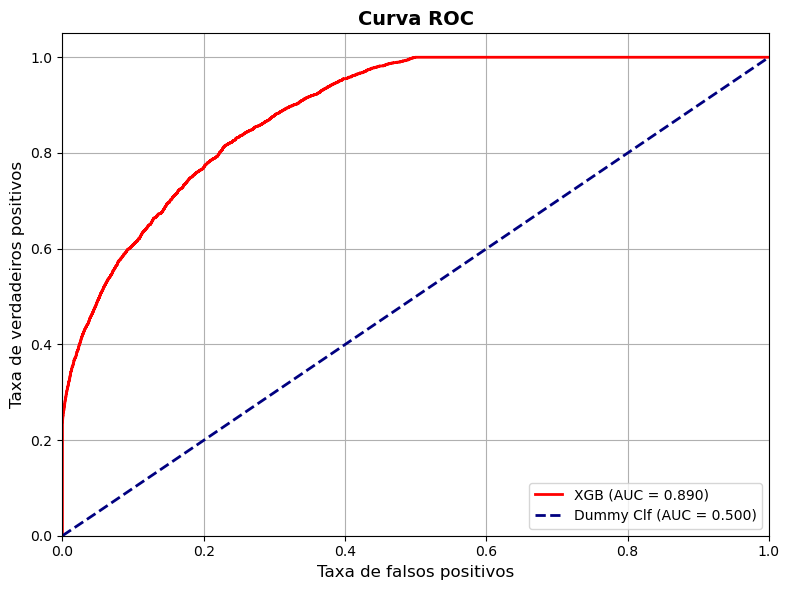

In [36]:
# curva ROC
from sklearn.metrics import roc_curve, auc
fpr_d, tpr_d, thresholds_d = roc_curve(y_train, dummy.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, pipeline.predict_proba(X_train)[:, 1])

# gráfico
plt.figure(figsize=(8, 6))

# Plot da curva ROC do seu Pipeline
plt.plot(fpr, tpr,
         color='red', 
         linewidth=2,
         label=f'XGB (AUC = {auc(fpr, tpr):.3f})')

# Plot da curva ROC do Dummy Classifier
plt.plot(fpr_d, tpr_d,
         color='navy', 
         linestyle='--',
         linewidth=2,
         label=f'Dummy Clf (AUC = {auc(fpr_d, tpr_d):.3f})')

# Configurações do gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de falsos positivos', fontsize=12)
plt.ylabel('Taxa de verdadeiros positivos', fontsize=12)
plt.title('Curva ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📊 Métricas de classificação: Precisão, Recall e F1-score

Para além da acurácia, é importante analisar métricas que avaliam diferentes aspectos do modelo:  

- **Precisão (Precision):** entre as instâncias previstas como positivas, quantas realmente eram positivas.  
- **Recall (Sensibilidade):** entre todas as instâncias positivas reais, quantas foram corretamente identificadas.  
- **F1-score:** média harmônica entre precisão e recall, balanceando as duas métricas.  

Aqui comparamos o desempenho do **DummyClassifier** com o modelo treinado,  
para verificar se o modelo realmente traz ganhos nessas métricas fundamentais.


In [38]:
# recall, precisão e f1 no TREINO
from sklearn.metrics import precision_score, recall_score, f1_score

# Predições no treino
y_pred_dummy = dummy.predict(X_train)
y_pred_modelo = pipeline.predict(X_train)

# Dummy
prec_dummy = precision_score(y_train, y_pred_dummy)
rec_dummy  = recall_score(y_train, y_pred_dummy)
f1_dummy   = f1_score(y_train, y_pred_dummy)

# XGB
prec_modelo = precision_score(y_train, y_pred_modelo)
rec_modelo  = recall_score(y_train, y_pred_modelo)
f1_modelo   = f1_score(y_train, y_pred_modelo)

# Exibição
print("=== Desempenho no TREINO ===")
print(f"Dummy → Precisão: {prec_dummy:.1%} | Recall: {rec_dummy:.1%} | F1: {f1_dummy:.1%}")
print(f"XGB   → Precisão: {prec_modelo:.1%} | Recall: {rec_modelo:.1%} | F1: {f1_modelo:.1%}")


=== Desempenho no TREINO ===
Dummy → Precisão: 4.8% | Recall: 4.7% | F1: 4.8%
XGB   → Precisão: 17.9% | Recall: 73.5% | F1: 28.8%


## **Endpoint**

Alcançamos um modelo final do XBG e avaliamos ele no conjunto de treinamento. Agora vamos salvar o modelo e avaliá-lo, com os demais, em uma estratégia de validação cruzada final. 

In [39]:
# salvar objeto pipeline completo
joblib.dump(pipeline, 'xgboost_pipeline_trained.joblib')

['xgboost_pipeline_trained.joblib']